# LINEAR REGRESSION MODEL PROYECT
For this analysis we are using Boston Dataset.

## Data Analysis



Importing basic libraries:

In [3]:
#Librerías básicas Python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from traitlets import observe
%matplotlib inline

Loading the data set:


In [4]:
    from sklearn.datasets import fetch_california_housing
    CA = fetch_california_housing()
    df = pd.DataFrame(CA.data, columns=CA.feature_names)
    df['Price'] = CA.target

In [5]:
print(df.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


In [6]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Lets visualize our data set for a better interpretation 

<Axes: >

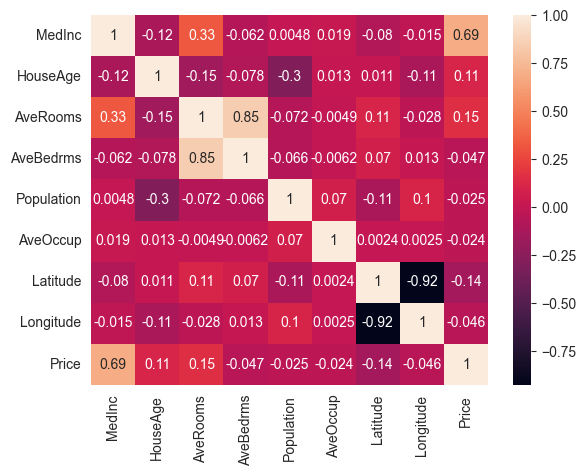

In [8]:
sns.heatmap(df.corr(), annot=True)

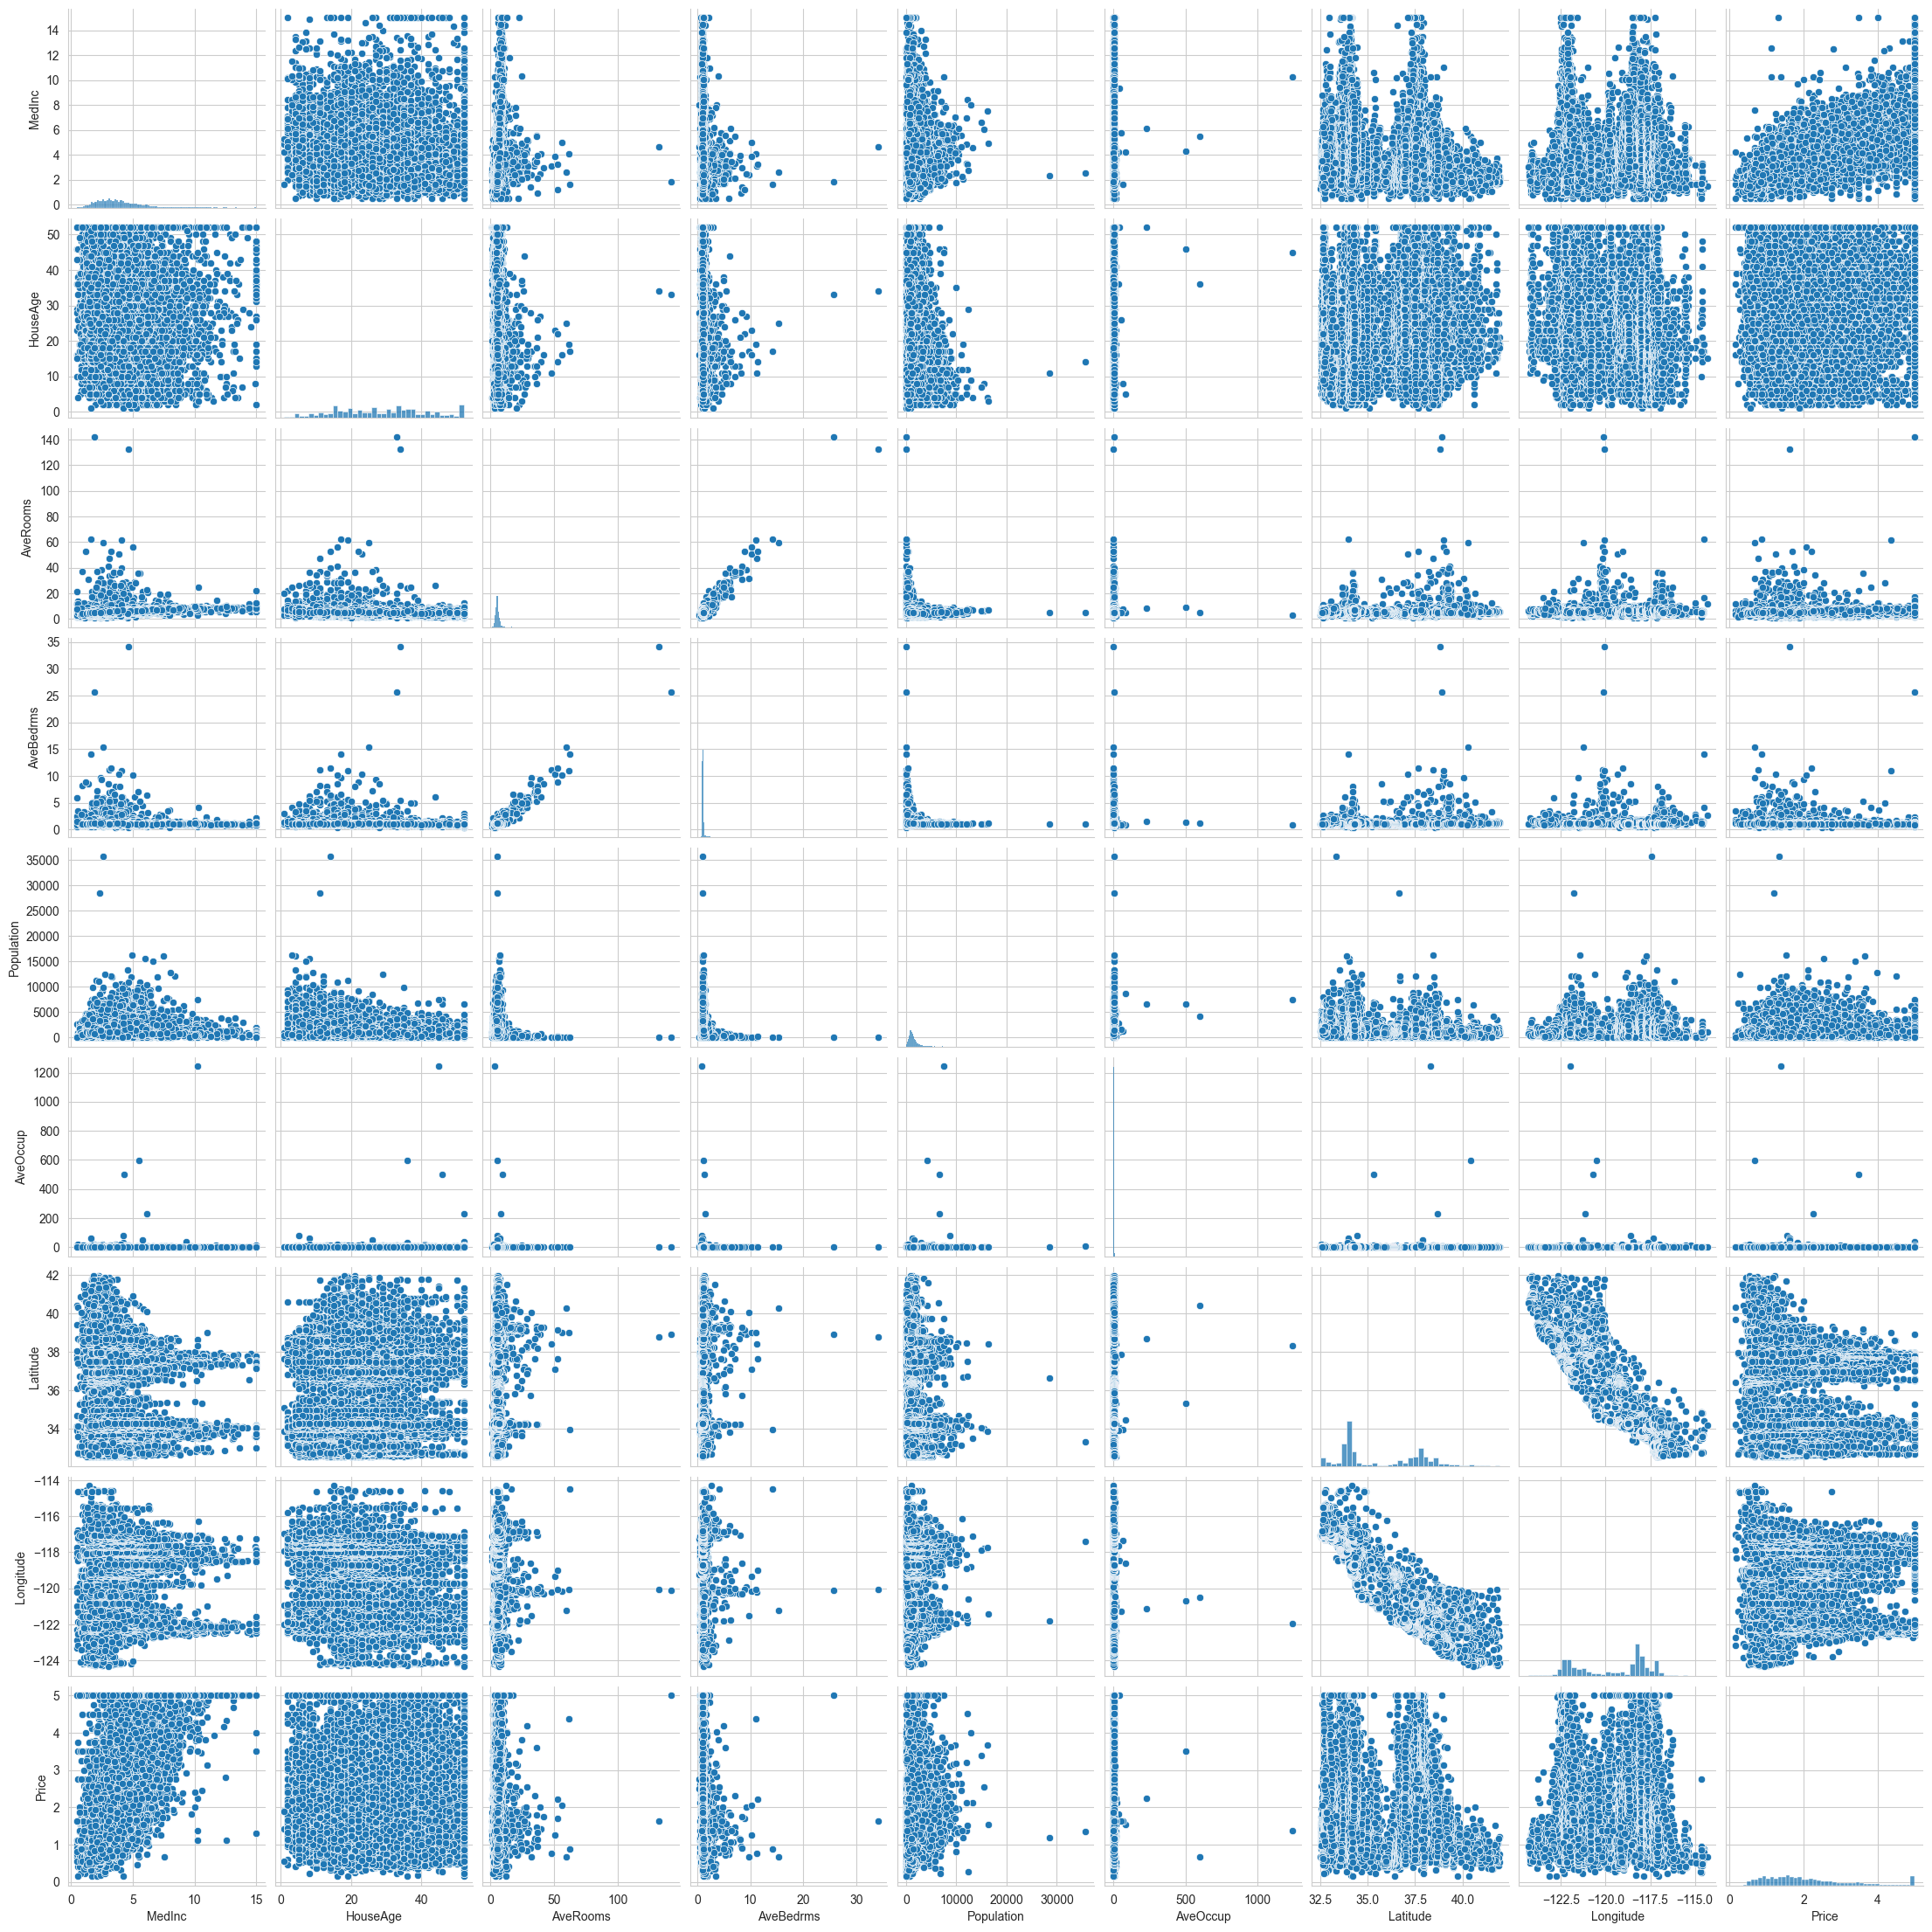

In [9]:
sns.pairplot(df)

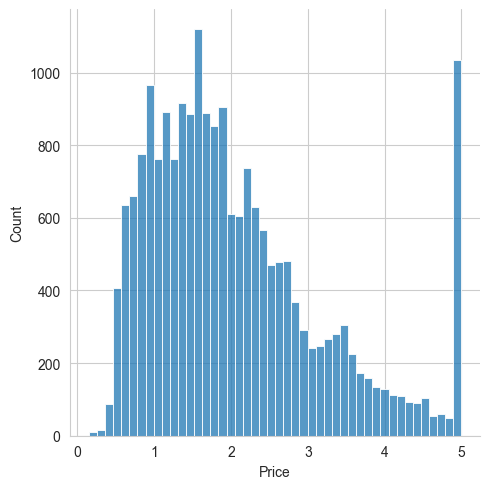

In [54]:
sns.displot(df['Price'])

#### OBSERVATION
After plotting, we notice that this data set is right-censoring, where values beyond 5 are assumed as 5.

First we are going to build the linear regression model based on the original data set.
After that we'll take values beyond 5 so we can build a linear regression with cleaner data.
Later we´ll see the difference between models.

## MODEL 1: Original Data
We define our X and Y values, divide them into the training and testing, and create the linear model.


In [10]:
# Visualizing column names
df.columns
X=df[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude']]
Y=df['Price']

In [11]:
# Diviving into training and testing values
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=101)


In [12]:
# Creating linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, Y_train)

lm.intercept_, lm.coef_


(np.float64(-35.31110661718541),
 array([ 4.30863349e-01,  1.02352181e-02, -1.04016683e-01,  5.37428718e-01,
         1.80375787e-05, -1.47742974e-01, -4.19256479e-01, -4.24321036e-01]))

In [13]:
coeff_df = pd.DataFrame(lm.coef_,X.columns,columns=['Coefficient'])
coeff_df

,Coefficient
MedInc,0.430863
HouseAge,0.010235
AveRooms,-0.104017
AveBedrms,0.537429
Population,0.000018
AveOccup,-0.147743
Latitude,-0.419256
Longitude,-0.424321


Ahora ya tenemos los coeficientes para nuestra regresión lineal
$$ y= -35.31 + 0.43x_1 +.0102 x_2 -0.104x_3 +0.537x_4 + 0.000018x_5 -0.147x_6 -0.419x_7 -0.424x_8$$

Now lets evaluate our model with some predictions and compare them to the y test values we split from the start. We are going to check the distribution of the residuals between them to prove if they are normally distributed.



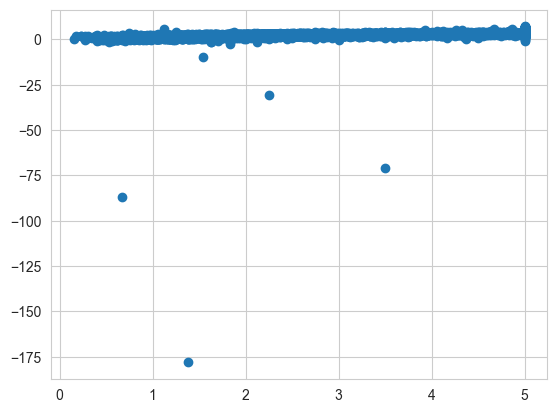

In [14]:
predictions = lm.predict(X_test)
plt.scatter(Y_test, predictions)

(-10.0, 10.0)

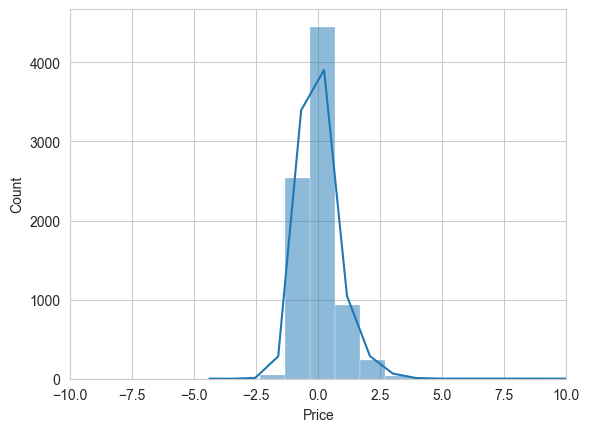

In [15]:
sns.histplot((Y_test-predictions), kde=True, );
plt.xlim(-10,10)


#### Regression Evaluation Metrics


In [16]:
from sklearn import metrics

MAE1=metrics.mean_absolute_error(Y_test, predictions)
MSE1=metrics.mean_squared_error(Y_test, predictions)
RMSE1=np.sqrt(metrics.mean_squared_error(Y_test, predictions))
print('MAE:', MAE1)
print('MSE:', MSE1)
print('RMSE:', RMSE1)

MAE: 0.5620561497050929
MSE: 6.160634987005654
RMSE: 2.4820626476794767


As we can observe, predictions don´t match the test values, and our residuals are not normally distributed.
Let´s try adjustig the original data set by taking away the values beyond 5.

## MODEL 2: Clean Data
After selecting only real data we will proceed on building the model on the same way we did for the fist one.


In [17]:
df_clean = df[df['Price'] < 5]


Let´s visualize our data again

In [18]:
df_clean.describe()



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000,19648.000000
mean,3.676411,28.373066,5.361708,1.096621,1441.368485,3.096560,35.651872,-119.562378,1.920553
std,1.570602,12.504050,2.293321,0.452136,1144.075196,10.639195,2.150066,2.005760,0.971109
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.526300,18.000000,4.416667,1.005882,796.000000,2.446614,33.930000,-121.760000,1.164750
50%,3.449050,28.000000,5.185730,1.048576,1179.000000,2.837779,34.270000,-118.500000,1.736000
75%,4.582500,37.000000,5.971083,1.099222,1746.250000,3.306021,37.730000,-117.990000,2.479000
max,15.000100,52.000000,132.533333,34.066667,35682.000000,1243.333333,41.950000,-114.310000,4.991000


<Axes: >

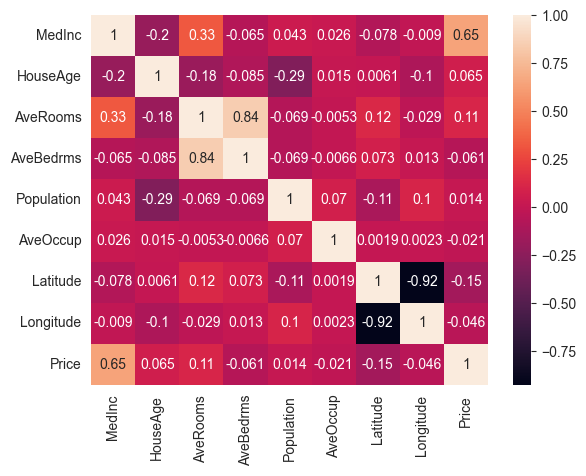

In [19]:
sns.heatmap(df_clean.corr(), annot=True)

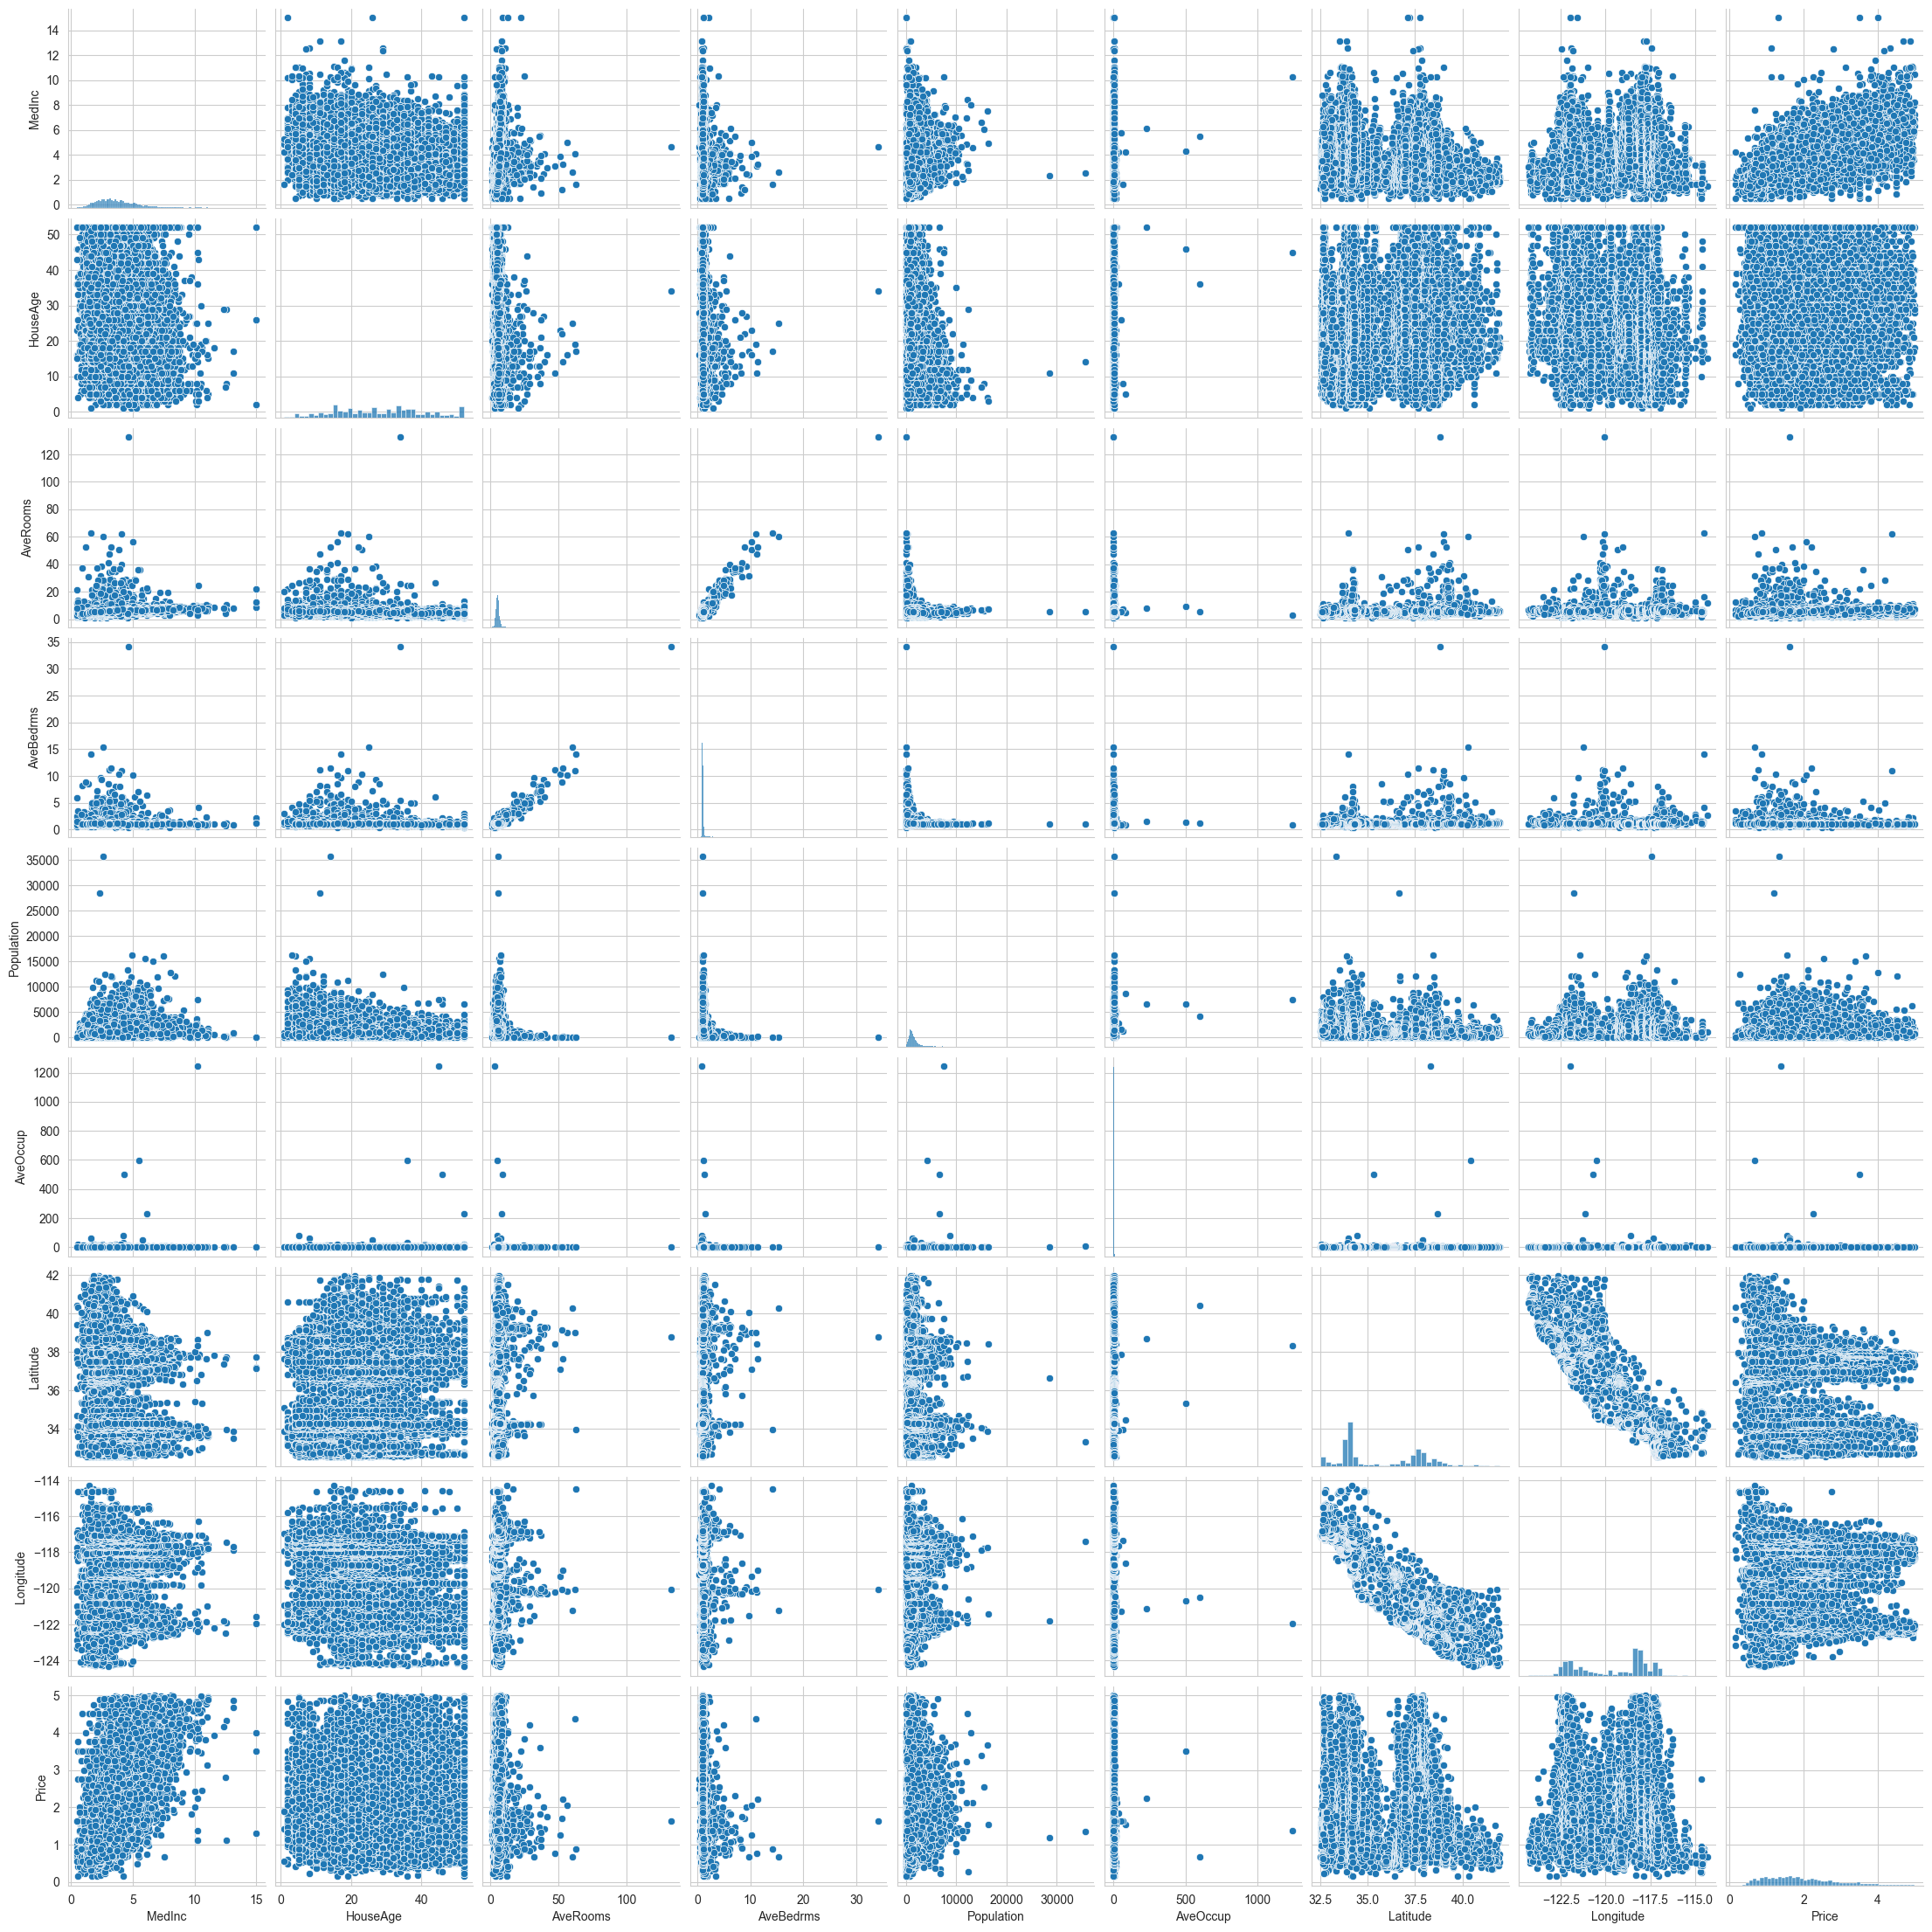

In [38]:
sns.pairplot(df_clean)

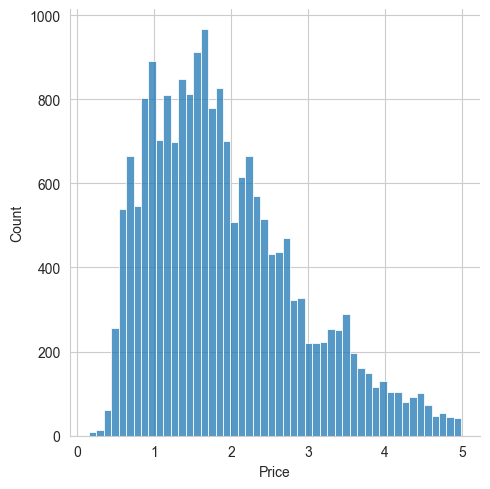

In [39]:
sns.displot(df_clean['Price'])


Now lets build our model again.

In [20]:
# Visualizing column names
df_clean.columns
X = df_clean[['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
        'Latitude', 'Longitude']]
Y = df_clean['Price']


# Diviving into training and testing values
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.4, random_state=101)

# Creating linear model
from sklearn.linear_model import LinearRegression
lm = LinearRegression()
lm.fit(X_train, Y_train)

lm.intercept_, lm.coef_


(np.float64(-34.84364152460196),
 array([ 4.29269581e-01,  8.37466900e-03, -1.06997833e-01,  6.65447704e-01,
         3.50698909e-06, -3.41592716e-03, -3.91626450e-01, -4.07811668e-01]))

In [21]:
coeff_df = pd.DataFrame(lm.coef_, X.columns, columns=['Coefficient'])
coeff_df

,Coefficient
MedInc,0.429270
HouseAge,0.008375
AveRooms,-0.106998
AveBedrms,0.665448
Population,0.000004
AveOccup,-0.003416
Latitude,-0.391626
Longitude,-0.407812


Now that we have our new values for the intercept and the coefficients, our linear equation model is:
$$ y= -34.84 + 0.429x_1 +.0083 x_2 -0.106x_3 +0.665x_4 + 0.000004x_5 -0.003x_6 -0.391x_7 -0.407x_8$$


The interesting part comes now, we are going to prove that this model fits better our data.
Lets compare predictions of our new model with our Y test values, and check the residuals between them are normally distributed.

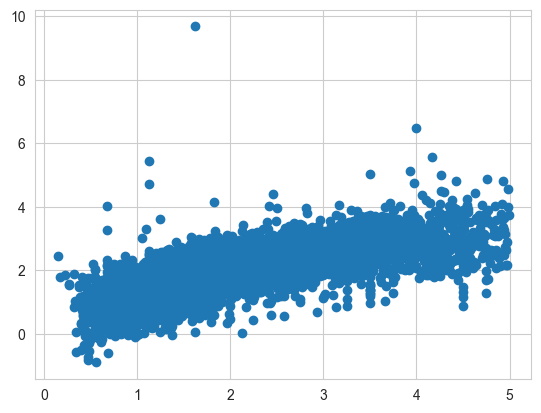

In [23]:
predictions = lm.predict(X_test)
plt.scatter(Y_test, predictions)


(-10.0, 10.0)

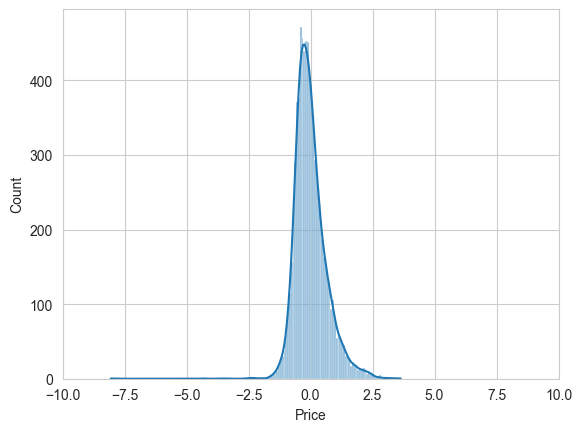

In [24]:

sns.histplot((Y_test - predictions), kde=True, );
plt.xlim(-10, 10)

As we can see, this model is way much better for our data set. Our predicted values look more alike to the y test values we asign in the beginning. Let´s calculate then some important metrics for a better analysis.


In [25]:
MAE2=metrics.mean_absolute_error(Y_test, predictions)
MSE2=metrics.mean_squared_error(Y_test, predictions)
RMSE2=np.sqrt(metrics.mean_squared_error(Y_test, predictions))
print('MAE:', MAE2)
print('MSE:', MSE2)
print('RMSE:', RMSE2)

MAE: 0.4765509597640189
MSE: 0.41145534861859556
RMSE: 0.6414478533899662


## COMPARISON


As we can observe on the table below, when we clean our data taking away the right censored values bigger than 5, we can build a better model that predicts closer tho our testing values.

In [27]:

results = pd.DataFrame({
    'Original data': [MAE1, MSE1, RMSE1],
    'Clean data': [MAE2, MSE2, RMSE2]
}, index=['MAE', 'MSE', 'RMSE'])

results


,Original data,Clean data
MAE,0.562056,0.476551
MSE,6.160635,0.411455
RMSE,2.482063,0.641448
